Description:

Analyze the relationship between the number of primary care appointments per head of population in sub-ICBs within SNEE (Suffolk and North East Essex) and staffing levels per head of population. The goal is to use the GP Patient list, the most recent appointments dataset, and the staffing dataset from NHSE (all currently available in the catalog) to investigate how the patient-to-GP ratio correlates with appointments per head specifically in the context of SNEE compared to broader English sub-ICBs.

Exam question/Objective:

Determine if staffing levels per head of population significantly affect the number of primary care appointments per head in sub-ICBs within SNEE. Additionally, assess whether the patient-to-GP ratio in SNEE reflects or deviates from the trends seen in other English sub-ICBs.

Stakeholder Request:

I want a report that details the relationship between the number of primary care appointments per head of population and staffing levels per head of population in sub-ICBs within SNEE. The report should highlight if variations in patient-to-GP ratios contribute to differences in appointments per head and whether these findings are consistent with or diverge from other English sub-ICBs.

Key Data Sources:

GP Patient list from NHSE
Most recent appointments dataset from NHSE
Staffing dataset from NHSE
Methodology/Approach:

Data extraction from NHSE catalog for GP Patient list, appointments data, and staffing data.
Clean and preprocess the datasets to ensure consistency.
Calculate patient-to-GP ratios and staffing levels per head of population.
Conduct initial exploratory data analysis (EDA) to understand distribution and correlations.
Apply statistical analysis (e.g., linear regression or correlation analysis) to assess relationships.
Compare results between SNEE sub-ICBs and other English sub-ICBs.
Visualize findings through charts and graphs.
Summarize insights in a report.
Outputs:

Branch in repo
Notebook
Markdown blog

## Library Imports

In [1]:
import os
from pathlib import Path
if 'notebooks' in str(Path.cwd()):
    os.chdir('..')

# Library imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from matplotlib.ticker import FuncFormatter
import datetime as dt
import pickle
from typing import Dict
from time import sleep
from datetime import timedelta
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy.stats import pearsonr

# project imports from src
from src.schemas import DataCatalog
from src.various_methods import PlotCounter, get_workingdays
from src import constants

# Importing SNEE styles
from sneeifstyles import mpl_style
mpl_style()

import warnings
warnings.filterwarnings("ignore")

## Initial Set-up

In [2]:
## Constants
SNEE_SUB_ICB = ['06L','06T','07K']
SNEE_SUB_ICB_NAMES = ['Ipswich & East Suffolk', 'North East Essex', 'West Suffolk']
NOTEBOOK_ALIAS = "Appointments"
GP_PATIENTS_LIST_CATALOG = 'Patients Registered at a GP practice, September 2024'
GP_APPOINTMENTS_CATALOG_NAME:str = 'Appointments in General Practice, August 2024'
GP_WORKFORCE_CATALOG:str = 'General Practice workforce'  # August/2024
GP_LIST_AGE_BANDS = constants.GP_LIST_AGE_BANDS 
GP_LIST_AGE_LABELS = constants.GP_LIST_AGE_LABELS 
SNEE_SUBICB_CODES = list(constants.ONS_CODES.keys())

# Loading the Data Catalog
catalog =  DataCatalog.load_from_yaml("data_catalog.yaml")

# Initializing the plotCounter object
plot_counter = PlotCounter(name=NOTEBOOK_ALIAS)

# set up output directories
for i in ['outputs/assumptions', 'outputs/plots', 'outputs/tables']:
    if not os.path.exists(i):
        os.makedirs(i)

## 1. GP list Loading and processing

In [3]:
def process_gp_list(df):
    """
    Args:
        df (pandas.DataFrame): GP LIST DataFrame. 
    Returns:
        pandas.DataFrame: 
    """
    df_ = df.copy()
    
    # Keeping only the total population both 'AGE_GROUP_5' and 'SEX' columns are 'ALL'
    df_ = df.loc[(df['AGE_GROUP_5'] == 'ALL') & (df['SEX'] == 'ALL')]
    
    # Filter rows to keep only those with ORG_TYPE as 'SUB_ICB_LOCATION_CODE'
    df_ = df_[df_['ORG_TYPE'].isin(['SUB_ICB_LOCATION_CODE'])].copy()
    
    df_ = df_.rename(columns={'ORG_CODE':'SUB_ICB_CODE'})

    # Dropping unused columns
    df_ = df_.drop(columns=['PUBLICATION','EXTRACT_DATE','ORG_TYPE','POSTCODE','SEX','AGE_GROUP_5']).reset_index(drop=True)
  
    return df_

In [4]:
gp_list_df = catalog.get_catalog_entry_by_name(GP_PATIENTS_LIST_CATALOG)
patients_df = gp_list_df.load()
patients_df = process_gp_list(patients_df)
patients_df.tail()

# # ICB level total
# icb_patients_df = patients_df[~patients_df['ICB'].isnull()].drop(columns={'SUB_ICB_LOCATION_CODE'}).reset_index(drop=True)
# icb_patients_df.tail()

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS
101,D9Y0V,E38000253,1730028
102,M1J4Y,E38000249,1140994
103,M2L0M,E38000257,534870
104,W2U3Z,E38000256,2899512
105,X2C4Y,E38000254,461152


## 2. Workforce Loading and processing

In [5]:
def process_workforce(df):
    """
    Args:
        df (pandas.DataFrame): Workforce DataFrame. 
    Returns:
        pandas.DataFrame: 
    """
    df_ = df.copy()
    
    # Dropping unused columns
    df_ = df_.drop(columns=['YEAR','Month','COMM_REGION_CODE','COMM_REGION_NAME','ICB_CODE','ICB_NAME','SUB_ICB_NAME','DATA_SOURCE','UNIQUE_IDENTIFIER','DETAILED_STAFF_ROLE',
                            'STAFF_ROLE','COUNTRY_QUALIFICATION_AREA','COUNTRY_QUALIFICATION_GROUP','AGE_BAND','AGE_YEARS','GENDER'])
    
    # Group by sub-icb and staff type
    df_ = df_.groupby(['SUB_ICB_CODE', 'STAFF_GROUP']).sum().round(2).reset_index()

    return df_

In [6]:
workforce_entry =  catalog.get_catalog_entry_by_name(GP_WORKFORCE_CATALOG)
workforce_df = workforce_entry.load()

# To match the names of icbs at the end
col = ['ICB_CODE','ICB_NAME','SUB_ICB_CODE','SUB_ICB_NAME']
icb_name_code_match = workforce_df[col].drop_duplicates().reset_index(drop=True)

workforce_df = process_workforce(workforce_df)
workforce_df.tail()

,SUB_ICB_CODE,STAFF_GROUP,FTE
420,W2U3Z,Nurses,374.31
421,X2C4Y,Admin/Non-Clinical,536.59
422,X2C4Y,Direct Patient Care,111.65
423,X2C4Y,GP,248.59
424,X2C4Y,Nurses,113.16


queation --> the FTE above is for one single day (should we multiply by number of working days and year to get full year worth of FTE)

## 3. Appointments Loading and processing (keeping 1 full year of appointments)

In [7]:
def process_appointments(df):
    """
    Args:
        df (pandas.DataFrame): Appointments DataFrame. 
    Returns:
        pandas.DataFrame: 
    """
    df_ = df.copy()
    
    # Convert the 'date_column' to datetime format
    df_['Appointment_Date'] = pd.to_datetime(df_['Appointment_Date'], format='%d%b%Y')

    # Calculate the date one year before the latest date
    one_year_ago = (df_['Appointment_Date'].max()) - timedelta(days=365)

    # Filter the DataFrame to get data from the last year
    df_ = df_[df_['Appointment_Date'] >= one_year_ago].reset_index(drop=True)
    
    # Dropping unused columns
    df_ = df_.drop(columns=['SUB_ICB_LOCATION_ONS_CODE','SUB_ICB_LOCATION_NAME','ICB_ONS_CODE','REGION_ONS_CODE','ACTUAL_DURATION'])
    
    # Group by 'SUB_ICB_LOCATION_CODE', and sum 'COUNT_OF_APPOINTMENTS' 
    df_ = df_.groupby(['SUB_ICB_LOCATION_CODE'])['COUNT_OF_APPOINTMENTS'].sum().reset_index().rename(columns={'SUB_ICB_LOCATION_CODE' : 'SUB_ICB_CODE'})
    

    return df_

In [8]:
appointments_catalog_entry = catalog.get_catalog_entry_by_name(GP_APPOINTMENTS_CATALOG_NAME)
appointments_df = appointments_catalog_entry.load()
appointments_df = process_appointments(appointments_df)
appointments_df

,SUB_ICB_CODE,COUNT_OF_APPOINTMENTS
0,00L,2089082
1,00N,712275
2,00P,1447505
3,00Q,793575
4,00R,960248
...,...,...
101,D9Y0V,9312912
102,M1J4Y,5231051
103,M2L0M,2774435
104,W2U3Z,13897197


## 4. Merging the datasets

In [9]:
appointments_vs_staffing_df = pd.merge(patients_df, appointments_df, on='SUB_ICB_CODE', how='inner')
appointments_vs_staffing_df = pd.merge(appointments_vs_staffing_df, workforce_df, on='SUB_ICB_CODE', how='right')
appointments_vs_staffing_df.tail()

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS,COUNT_OF_APPOINTMENTS,STAFF_GROUP,FTE
420,W2U3Z,E38000256,2899512.0,13897197.0,Nurses,374.31
421,X2C4Y,E38000254,461152.0,2972654.0,Admin/Non-Clinical,536.59
422,X2C4Y,E38000254,461152.0,2972654.0,Direct Patient Care,111.65
423,X2C4Y,E38000254,461152.0,2972654.0,GP,248.59
424,X2C4Y,E38000254,461152.0,2972654.0,Nurses,113.16


## 5. Determine relationship between: Staffing level per head of population VS. Primary care appointments per head of population
### 5.1. All SUB ICB'S

In [10]:
appointments_vs_staffing_df['Appointments_per_head'] = (appointments_vs_staffing_df['COUNT_OF_APPOINTMENTS'] / appointments_vs_staffing_df['NUMBER_OF_PATIENTS']).round(2)
appointments_vs_staffing_df['Staffing_per_head'] = appointments_vs_staffing_df['FTE'] / appointments_vs_staffing_df['NUMBER_OF_PATIENTS']
appointments_vs_staffing_df['Patient_to_gp_Ratio'] = (appointments_vs_staffing_df['NUMBER_OF_PATIENTS'] / appointments_vs_staffing_df['FTE']).round(2)

# Filtering for only GP
appointments_vs_staffing_gp_df = appointments_vs_staffing_df[appointments_vs_staffing_df['STAFF_GROUP'] == 'GP'].dropna().reset_index(drop=True)
appointments_vs_staffing_gp_df.tail()

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS,COUNT_OF_APPOINTMENTS,STAFF_GROUP,FTE,Appointments_per_head,Staffing_per_head,Patient_to_gp_Ratio
101,D9Y0V,E38000253,1730028.0,9312912.0,GP,1019.23,5.38,0.000589,1697.39
102,M1J4Y,E38000249,1140994.0,5231051.0,GP,527.11,4.58,0.000462,2164.62
103,M2L0M,E38000257,534870.0,2774435.0,GP,311.06,5.19,0.000582,1719.51
104,W2U3Z,E38000256,2899512.0,13897197.0,GP,1302.45,4.79,0.000449,2226.20
105,X2C4Y,E38000254,461152.0,2972654.0,GP,248.59,6.45,0.000539,1855.07


In [11]:
# Calculate national averages
national_avg_staffing = appointments_vs_staffing_gp_df['Staffing_per_head'].mean()
national_avg_appointments = appointments_vs_staffing_gp_df['Appointments_per_head'].mean()

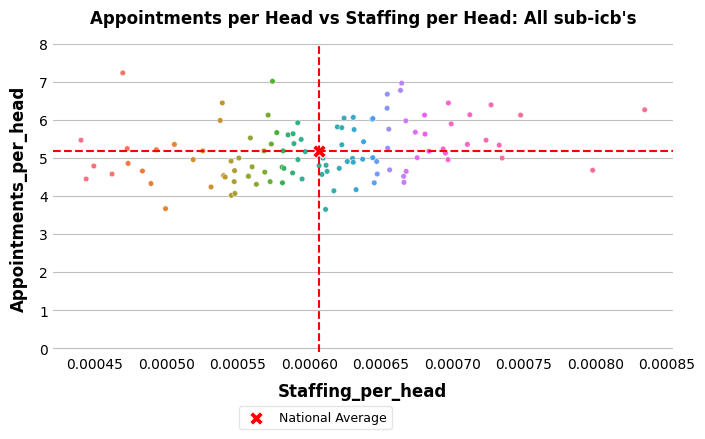

In [44]:
# Scatter plot: Appointments per head vs Staffing per head
plt.figure(figsize=(8, 4))
sns.scatterplot(data=appointments_vs_staffing_gp_df, x='Staffing_per_head', y='Appointments_per_head', hue='SUB_ICB_CODE', legend=False)
sns.scatterplot(x=[national_avg_staffing], y=[national_avg_appointments], color='red', marker='X', s=100, label='National Average')
plt.axhline(y=national_avg_appointments, color='red', linestyle='--')
plt.axvline(x=national_avg_staffing, color='red', linestyle='--')
plt.title("Appointments per Head vs Staffing per Head: All sub-icb's")
plt.legend(loc =(0.3,-0.25), ncol=1)
plt.ylim(-0.1,8)
plt.show()

In [47]:
# Correlation analysis
correlation, p_value = pearsonr(appointments_vs_staffing_gp_df['Staffing_per_head'], appointments_vs_staffing_gp_df['Appointments_per_head'])
print(f"Correlation: {correlation}, P-value: {p_value}")

Correlation: 0.29071267764606884, P-value: 0.002501512054517499


**Interpretation:**
- The correlation coefficient (0.2907) indicates a positive but weak relationship between staffing levels per head and appointments per head. This means that, as staffing levels per head increase, there is a tendency for appointments per head to also increase, but the effect is not very strong.
- The P-value (0.0025) is less than the standard significance threshold (0.05), suggesting that this correlation is statistically significant. We can reject the null hypothesis of no relationship.

In [48]:
# Regression analysis
X = appointments_vs_staffing_gp_df[['Staffing_per_head']]  # Predictor
y = appointments_vs_staffing_gp_df['Appointments_per_head']  # Target
X = sm.add_constant(X)  # Add constant for intercept
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Appointments_per_head   R-squared:                       0.085
Model:                               OLS   Adj. R-squared:                  0.076
Method:                    Least Squares   F-statistic:                     9.601
Date:                   Fri, 15 Nov 2024   Prob (F-statistic):            0.00250
Time:                           16:11:50   Log-Likelihood:                -114.22
No. Observations:                    106   AIC:                             232.4
Df Residuals:                        104   BIC:                             237.8
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const   

- Intercept (const = 3.4634):
When Staffing_per_head is zero, the model predicts Appointments_per_head to be 3.4634. While this is unlikely in a real-world context, it serves as the baseline for the model.
- Slope (2853.0158):
For every one-unit increase in Staffing_per_head (staff per patient), Appointments_per_head is predicted to increase by 2853.0158 units.
- The slope is statistically significant since its p-value is less than 0.05. This indicates that staffing levels per head significantly influence appointments per head.
  
There is a statistically significant positive relationship between staffing levels per head and appointments per head, though the strength of the relationship (as indicated by R-squared and correlation) is weak.

### 5.1. SNEE SUB ICB'S

In [15]:
appointments_vs_staffing_snee = appointments_vs_staffing_gp_df[appointments_vs_staffing_gp_df['SUB_ICB_CODE'].isin(SNEE_SUB_ICB)]
appointments_vs_staffing_snee

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS,COUNT_OF_APPOINTMENTS,STAFF_GROUP,FTE,Appointments_per_head,Staffing_per_head,Patient_to_gp_Ratio
50,06L,E38000086,418013.0,2312991.0,GP,233.53,5.53,0.000559,1789.98
53,06T,E38000117,377220.0,2022802.0,GP,190.70,5.36,0.000506,1978.08
56,07K,E38000204,279496.0,1672428.0,GP,186.53,5.98,0.000667,1498.40


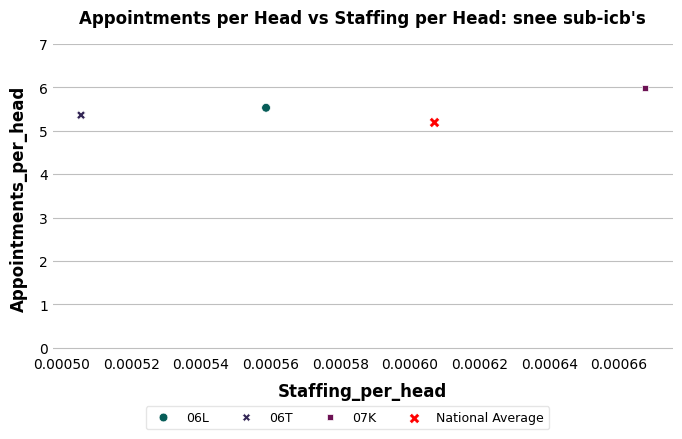

In [16]:
# Scatter plot: Appointments per head vs Staffing per head
plt.figure(figsize=(8, 4))
sns.scatterplot(data=appointments_vs_staffing_snee, x='Staffing_per_head', y='Appointments_per_head', hue='SUB_ICB_CODE', style='SUB_ICB_CODE', s=40)
# Add national average point
sns.scatterplot(x=[national_avg_staffing], y=[national_avg_appointments], color='red', marker='X', s=60, label='National Average')
plt.title("Appointments per Head vs Staffing per Head: snee sub-icb's")
plt.legend(loc =(0.15,-0.25), ncol=4)
plt.ylim(-0.1,7)
plt.show()

In [17]:
# Correlation analysis
correlation, p_value = pearsonr(appointments_vs_staffing_snee['Staffing_per_head'], appointments_vs_staffing_snee['Appointments_per_head'])
print(f"Correlation: {correlation}, P-value: {p_value}")

Correlation: 0.998242390208948, P-value: 0.037750263113562756


- The correlation coefficient (0.9982) is nearly perfect, suggesting that staffing levels per head almost entirely determine appointments per head in SNEE SUB-ICBs.

## 6. Determine relationshiop between patient to GP ratios in All sub icb's

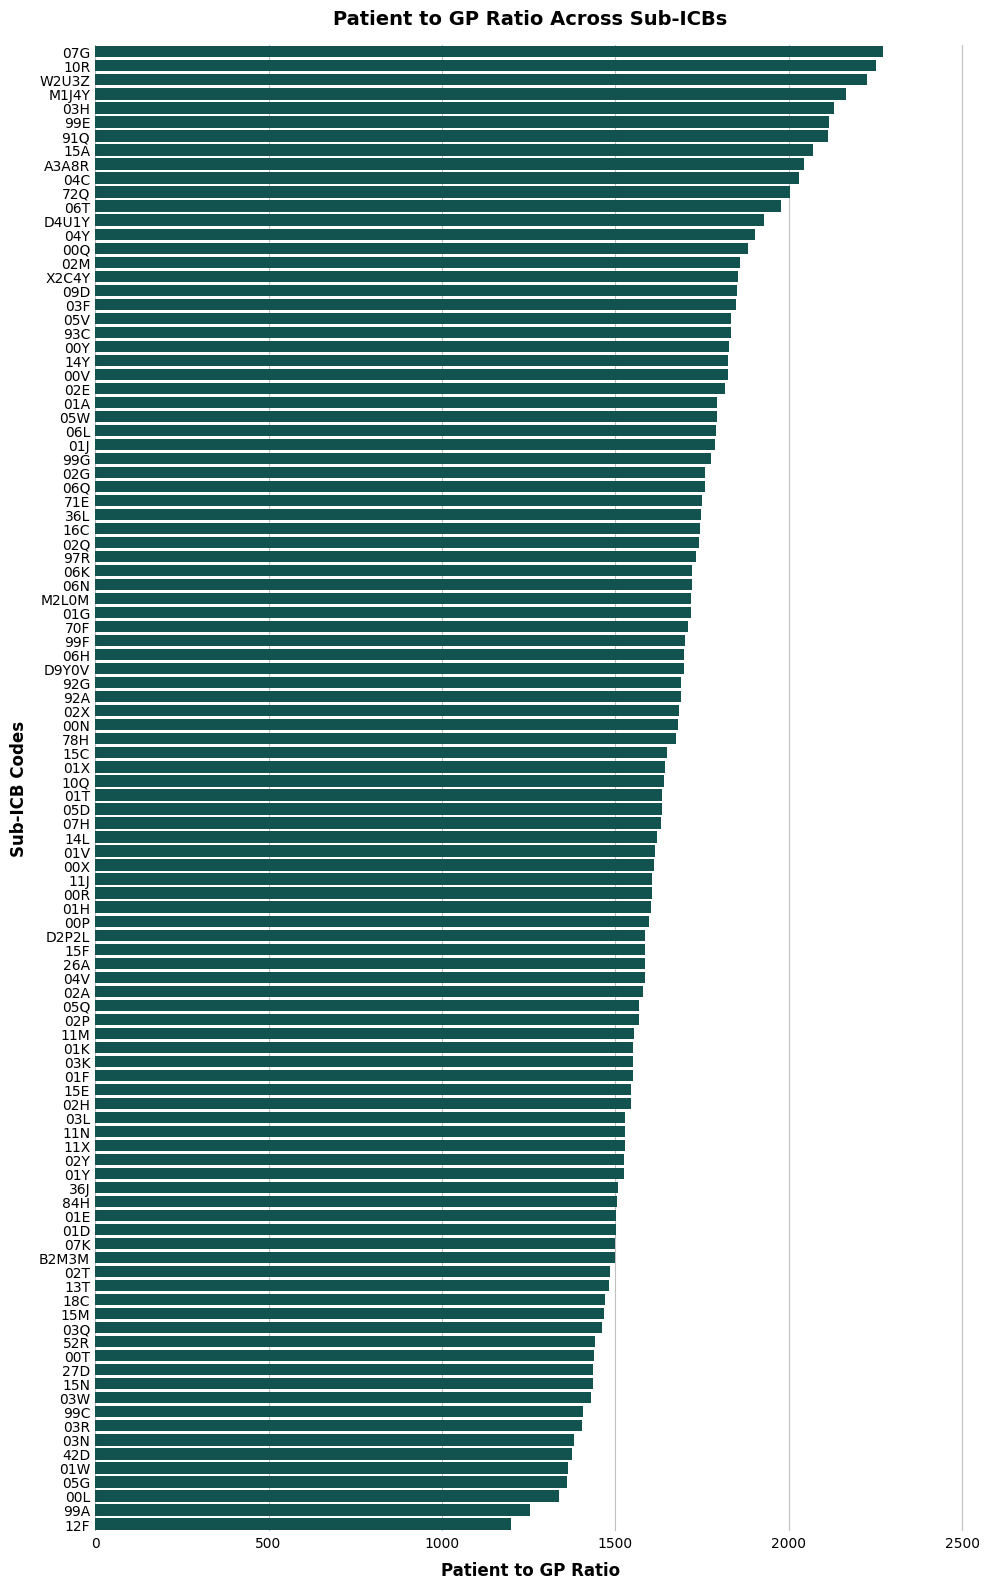

In [56]:
# Set the figure size
plt.figure(figsize=(10, 16))

# Create the horizontal bar plot
sns.barplot(x='Patient_to_gp_Ratio', y='SUB_ICB_CODE', data=appointments_vs_staffing_gp_df.sort_values(by='Patient_to_gp_Ratio', ascending=False))

# Add labels and title
plt.xlabel('Patient to GP Ratio', fontsize=12)
plt.ylabel('Sub-ICB Codes', fontsize=12)
plt.title('Patient to GP Ratio Across Sub-ICBs', fontsize=14)
plt.grid(axis='x')
plt.xlim(0,2510)
plt.tight_layout()
plt.show()

In [21]:
icb_name_code_match

,ICB_CODE,ICB_NAME,SUB_ICB_CODE,SUB_ICB_NAME
0,QJ2,NHS Derby and Derbyshire ICB,15M,NHS Derby and Derbyshire ICB - 15M
1,QK1,"NHS Leicester, Leicestershire and Rutland ICB",03W,"NHS Leicester, Leicestershire and Rutland ICB ..."
2,QK1,"NHS Leicester, Leicestershire and Rutland ICB",04V,"NHS Leicester, Leicestershire and Rutland ICB ..."
3,QK1,"NHS Leicester, Leicestershire and Rutland ICB",04C,"NHS Leicester, Leicestershire and Rutland ICB ..."
4,QT1,NHS Nottingham and Nottinghamshire ICB,52R,NHS Nottingham and Nottinghamshire ICB - 52R N...
...,...,...,...,...
102,QRL,NHS Hampshire and Isle Of Wight ICB,10R,NHS Hampshire and Isle Of Wight ICB - 10R Port...
103,QOX,"NHS Bath and North East Somerset, Swindon and ...",92G,"NHS Bath and North East Somerset, Swindon and ..."
104,QU9,"NHS Buckinghamshire, Oxfordshire and Berkshire...",14Y,"NHS Buckinghamshire, Oxfordshire and Berkshire..."
105,QU9,"NHS Buckinghamshire, Oxfordshire and Berkshire...",10Q,"NHS Buckinghamshire, Oxfordshire and Berkshire..."


In [23]:
appointments_vs_staffing_gp_df = pd.merge(appointments_vs_staffing_gp_df, icb_name_code_match, on='SUB_ICB_CODE', how='left')
appointments_vs_staffing_gp_df

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS,COUNT_OF_APPOINTMENTS,STAFF_GROUP,FTE,Appointments_per_head,Staffing_per_head,Patient_to_gp_Ratio,ICB_CODE,ICB_NAME,SUB_ICB_NAME
0,07G,E38000185,190410.0,1041337.0,GP,83.83,5.47,0.000440,2271.38,QH8,NHS Mid and South Essex ICB,NHS Mid and South Essex ICB - 07G Thurrock
1,10R,E38000137,235144.0,1046482.0,GP,104.37,4.45,0.000444,2252.98,QRL,NHS Hampshire and Isle Of Wight ICB,NHS Hampshire and Isle Of Wight ICB - 10R Port...
2,W2U3Z,E38000256,2899512.0,13897197.0,GP,1302.45,4.79,0.000449,2226.20,QRV,NHS North West London ICB,NHS North West London ICB - W2U3Z
3,M1J4Y,E38000249,1140994.0,5231051.0,GP,527.11,4.58,0.000462,2164.62,QHG,"NHS Bedfordshire, Luton and Milton Keynes ICB","NHS Bedfordshire, Luton and Milton Keynes ICB ..."
4,03H,E38000119,174713.0,1265285.0,GP,82.02,7.24,0.000469,2130.13,QOQ,NHS Humber and North Yorkshire ICB,NHS Humber and North Yorkshire ICB - 03H North...
...,...,...,...,...,...,...,...,...,...,...,...,...
101,01W,E38000174,328538.0,1754108.0,GP,240.72,5.34,0.000733,1364.81,QOP,NHS Greater Manchester ICB,NHS Greater Manchester ICB - 01W Stockport
102,05G,E38000126,230870.0,1153880.0,GP,169.63,5.00,0.000735,1361.02,QNC,NHS Staffordshire and Stoke-on-Trent ICB,NHS Staffordshire and Stoke-on-Trent ICB - 05G...
103,00L,E38000130,340837.0,2089082.0,GP,254.83,6.13,0.000748,1337.51,QHM,NHS North East and North Cumbria ICB,NHS North East and North Cumbria ICB - 00L Nor...
104,99A,E38000101,590170.0,2764711.0,GP,470.98,4.68,0.000798,1253.07,QYG,NHS Cheshire and Merseyside ICB,NHS Cheshire and Merseyside ICB - 99A Liverpool


In [31]:
appointments_vs_staffing_gp_df['ICB_NAME'].nunique()

42

In [37]:
appointments_vs_staffing_gp_df[appointments_vs_staffing_gp_df['ICB_NAME'] == 'NHS Suffolk and North East Essex ICB']

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS,COUNT_OF_APPOINTMENTS,STAFF_GROUP,FTE,Appointments_per_head,Staffing_per_head,Patient_to_gp_Ratio,ICB_CODE,ICB_NAME,SUB_ICB_NAME
11,06T,E38000117,377220.0,2022802.0,GP,190.70,5.36,0.000506,1978.08,QJG,NHS Suffolk and North East Essex ICB,NHS Suffolk and North East Essex ICB - 06T Nor...
27,06L,E38000086,418013.0,2312991.0,GP,233.53,5.53,0.000559,1789.98,QJG,NHS Suffolk and North East Essex ICB,NHS Suffolk and North East Essex ICB - 06L Ips...
85,07K,E38000204,279496.0,1672428.0,GP,186.53,5.98,0.000667,1498.40,QJG,NHS Suffolk and North East Essex ICB,NHS Suffolk and North East Essex ICB - 07K Wes...


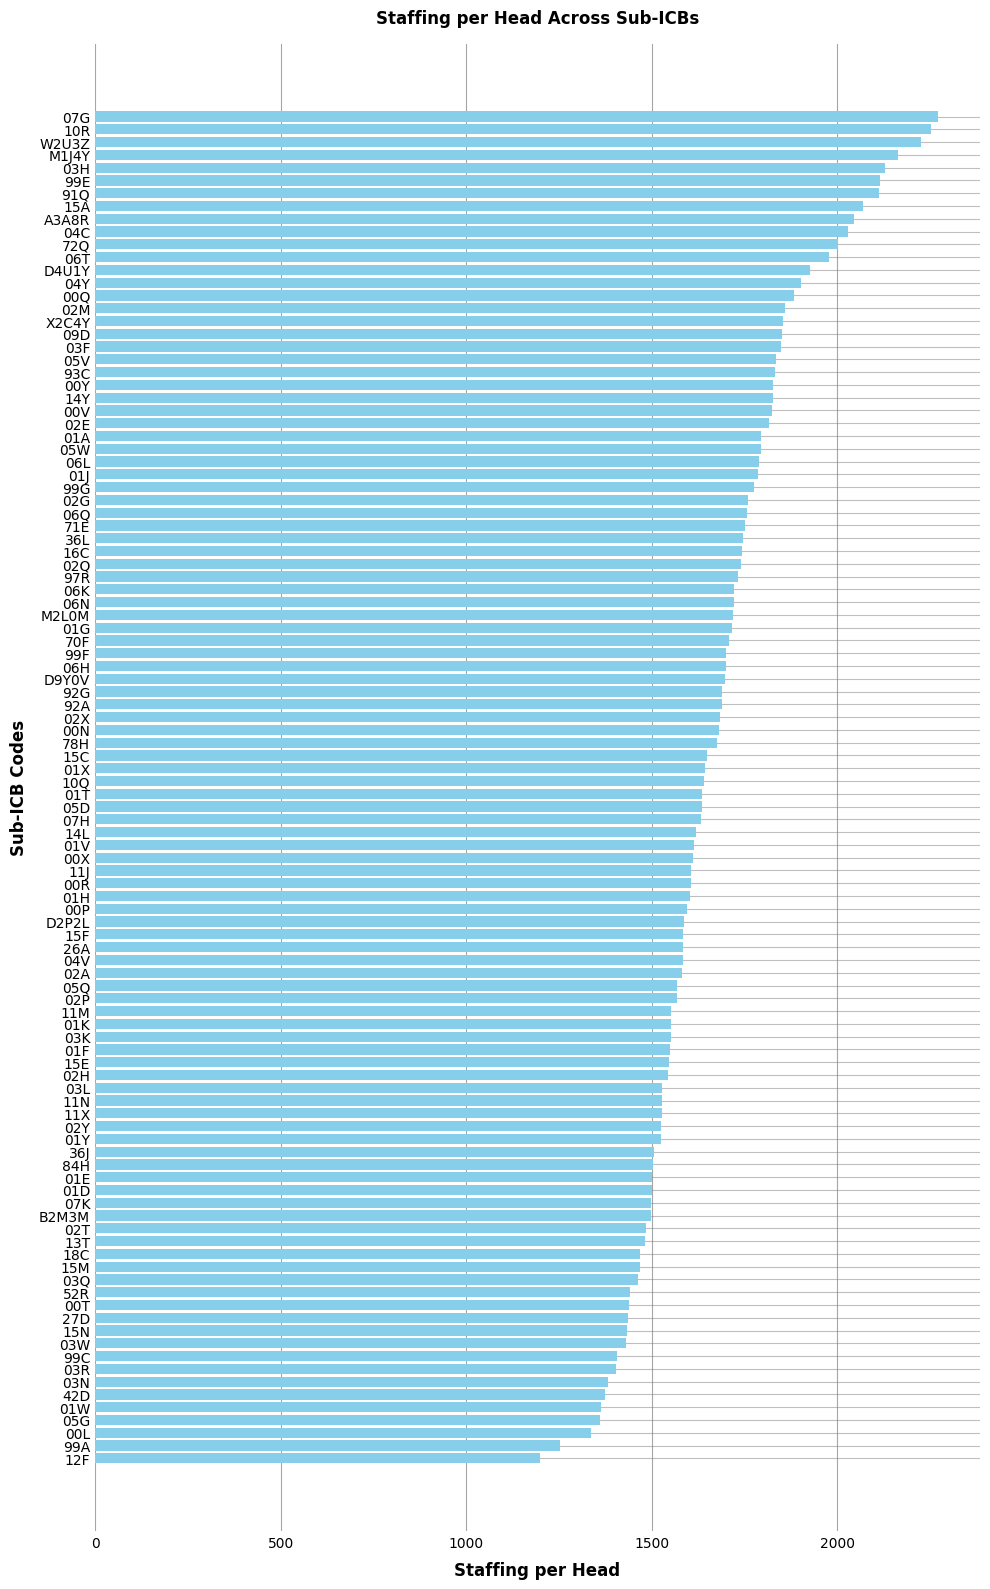

In [49]:
appointments_vs_staffing_gp_df = appointments_vs_staffing_gp_df.sort_values(by='Patient_to_gp_Ratio', ascending=True)
plt.figure(figsize=(10, 16))
plt.barh(appointments_vs_staffing_gp_df['SUB_ICB_CODE'], appointments_vs_staffing_gp_df['Patient_to_gp_Ratio'], color='skyblue')

# Add labels and title
plt.xlabel('Staffing per Head')
plt.ylabel('Sub-ICB Codes')
plt.title('Staffing per Head Across Sub-ICBs')

# Add grid for better readability
plt.grid(axis='x', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

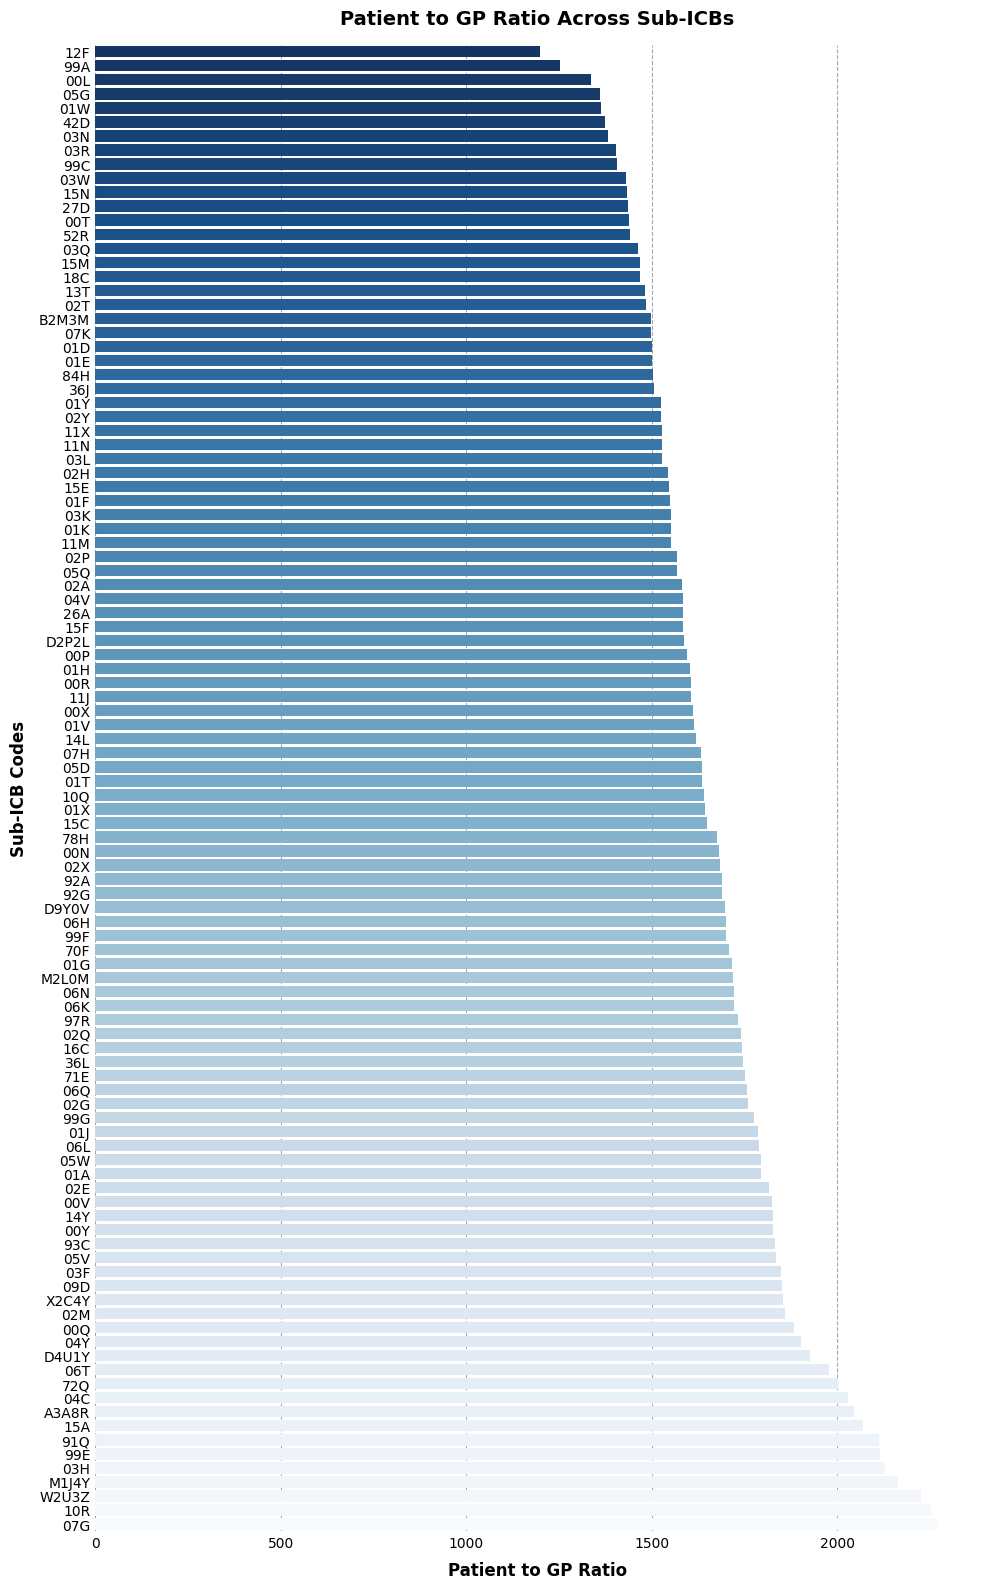

In [18]:
date_range_df = pd.DataFrame(pd.date_range(start=dt.date(year=2023,month=9,day=1), end=dt.date(year=2024,month=8,day=31), freq='MS')).rename(columns={0:'DATE'})
# Get working days/month
date_range_df['working_days'] = get_workingdays(date_range_df['DATE'].dt)

print(f'Total working days from 2023-09-01 to 2024-08-31 are: {date_range_df['working_days'].sum()}')

date_range_df.head()

Total working days from 2023-09-01 to 2024-08-31 are: 255


,DATE,working_days
0,2023-09-01,21
1,2023-10-01,22
2,2023-11-01,22
3,2023-12-01,19
4,2024-01-01,22
